In [ ]:
# Import basic libraries for computation and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st
from google.colab import files

# Machine learning models and metrics
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, fbeta_score, precision_recall_curve, auc

# Libraries for handling class imbalance
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks, RandomUnderSampler
from imblearn.combine import SMOTETomek

# Plot style settings
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore') # Disable warnings for a clean console output

In [ ]:
print("Please select the dataset file (e.g., creditcard.csv):")
uploaded = files.upload()

# Get the name of the uploaded file and load it into a DataFrame
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

print(f"\n Data successfully loaded! Dataset shape: {df.shape}")
df.head()

Please select the dataset file (e.g., creditcard.csv):


Saving creditcard.csv to creditcard.csv

✅ Data successfully loaded! Dataset shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


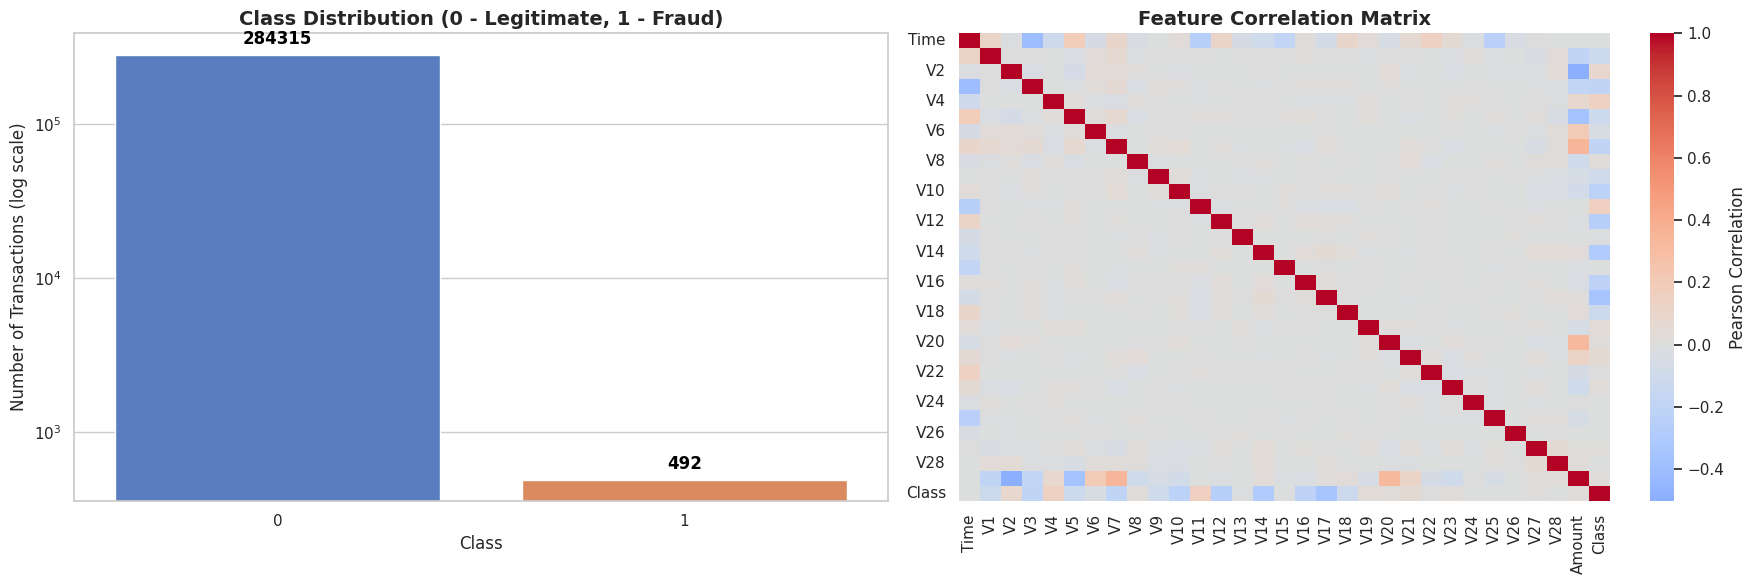

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: Class Imbalance
sns.countplot(x='Class', data=df, palette='muted', ax=axes[0])
axes[0].set_title('Class Distribution (0 - Legitimate, 1 - Fraud)', fontsize=14, fontweight='bold')
axes[0].set_yscale('log') # Logarithmic scale due to extreme class imbalance
axes[0].set_ylabel('Number of Transactions (log scale)')

# Add value labels above the bars
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold', color='black', xytext=(0, 5),
                textcoords='offset points')

# Plot 2: Correlation Heatmap
sample_df = df.sample(frac=0.1, random_state=42)
corr_matrix = sample_df.corr()
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, ax=axes[1], cbar_kws={'label': 'Pearson Correlation'})
axes[1].set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# 1. Split into features (X) and target (y)
X = df.drop(columns=['Time', 'Class'])
y = df['Class']

# 2. Cross-validation setup (5 splits, 2 repeats = 10 iterations per model)
N_SPLITS = 5
N_REPEATS = 2
rskf = RepeatedStratifiedKFold(n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=42)

# 3. Baseline model configurations
lr_base = LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs', random_state=42)
rf_base = RandomForestClassifier(n_estimators=100, max_depth=15, min_samples_leaf=2, criterion='gini', random_state=42, n_jobs=-1)
xgb_base = XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, reg_lambda=1.0, scale_pos_weight=1, random_state=42, n_jobs=-1)

# 4. Cost-Sensitive model configurations
lr_cost = LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs', class_weight='balanced', random_state=42)
rf_cost = RandomForestClassifier(n_estimators=100, max_depth=15, min_samples_leaf=2, criterion='gini', class_weight='balanced', random_state=42, n_jobs=-1)
xgb_cost = XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, reg_lambda=1.0, scale_pos_weight=578, random_state=42, n_jobs=-1)

# Global list to store the final metrics for the comparison plot
all_scenarios_results = []

In [ ]:
def evaluate_statistical_pipeline(get_pipeline_func, model_name, scenario_name):
    """
    Runs Repeated CV, mathematically optimizes the decision threshold for F2-score
    on each fold, and calculates mean, std, and 95% confidence intervals.
    """
    print(f"=== {model_name} ({scenario_name}) ===")

    fold_accuracies, fold_precisions, fold_recalls = [], [], []
    fold_f2_scores, fold_pr_aucs, fold_thresholds = [], [], []

    # Iterate over all folds
    for fold_idx, (train_idx, val_idx) in enumerate(rskf.split(X, y)):
        X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
        y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]

        # Create a fresh pipeline instance for the current fold to prevent data leakage
        pipe = get_pipeline_func()
        pipe.fit(X_train_fold, y_train_fold)

        # Get raw probabilities for the validation fold
        y_proba = pipe.predict_proba(X_val_fold)[:, 1]

        # Mathematical optimization of the cutoff threshold for the F2 metric
        best_t, best_f2 = 0.5, -1.0
        # Scan the threshold grid from 0.01 to 0.99
        for t in np.linspace(0.01, 0.99, 99):
            y_pred_t = (y_proba >= t).astype(int)
            current_f2 = fbeta_score(y_val_fold, y_pred_t, beta=2, zero_division=0)
            if current_f2 > best_f2:
                best_f2 = current_f2
                best_t = t

        # Final prediction based on the optimal threshold found
        y_pred_optimal = (y_proba >= best_t).astype(int)
        precision_vals, recall_vals, _ = precision_recall_curve(y_val_fold, y_proba)

        # Store metrics for the current fold
        fold_accuracies.append(accuracy_score(y_val_fold, y_pred_optimal))
        fold_precisions.append(precision_score(y_val_fold, y_pred_optimal, zero_division=0))
        fold_recalls.append(recall_score(y_val_fold, y_pred_optimal))
        fold_f2_scores.append(best_f2)
        fold_pr_aucs.append(auc(recall_vals, precision_vals))
        fold_thresholds.append(best_t)

    # Calculate Mean, Std, and 95% CI for each metric
    metrics_data = {
        'Accuracy': fold_accuracies, 'Precision': fold_precisions, 'Recall': fold_recalls,
        'F2-score': fold_f2_scores, 'PR-AUC': fold_pr_aucs, 'Opt. Threshold': fold_thresholds
    }

    for metric_name, fold_values in metrics_data.items():
        mean_val = np.mean(fold_values)
        std_val = np.std(fold_values)
        n_obs = len(fold_values)

        # Confidence interval using Student's t-distribution
        ci_bound = st.t.ppf(0.975, df=n_obs-1) * (std_val / np.sqrt(n_obs)) if std_val > 0 else 0

        if metric_name in ['F2-score', 'PR-AUC']:
            all_scenarios_results.append({
                'Model': model_name, 'Scenario': scenario_name, 'Metric': metric_name, 'Mean': mean_val
            })

        print(f"  {metric_name}: {mean_val:.4f} ± {std_val:.4f}  CI_95: [{mean_val-ci_bound:.4f}, {mean_val+ci_bound:.4f}]")
    print("-" * 50)

In [10]:
print("STARTING EXPERIMENTAL MODELING\n")

# ==========================================
# Scenario 0: Baseline (No balancing)
# ==========================================
evaluate_statistical_pipeline(lambda: Pipeline([('scaler', RobustScaler()), ('classifier', lr_base)]), 'Logistic Regression', 'Baseline')
evaluate_statistical_pipeline(lambda: Pipeline([('scaler', RobustScaler()), ('classifier', rf_base)]), 'Random Forest', 'Baseline')
evaluate_statistical_pipeline(lambda: Pipeline([('scaler', RobustScaler()), ('classifier', xgb_base)]), 'XGBoost', 'Baseline')

STARTING EXPERIMENTAL MODELING

=== Logistic Regression (Baseline) ===
  Accuracy: 0.9991 ± 0.0001  CI_95: [0.9990, 0.9992]
  Precision: 0.7194 ± 0.0505  CI_95: [0.6833, 0.7555]
  Recall: 0.8212 ± 0.0352  CI_95: [0.7960, 0.8463]
  F2-score: 0.7973 ± 0.0265  CI_95: [0.7784, 0.8163]
  PR-AUC: 0.7589 ± 0.0211  CI_95: [0.7438, 0.7739]
  Opt. Threshold: 0.0500 ± 0.0214  CI_95: [0.0347, 0.0653]
--------------------------------------------------
=== Random Forest (Baseline) ===
  Accuracy: 0.9995 ± 0.0001  CI_95: [0.9994, 0.9996]
  Precision: 0.8764 ± 0.0426  CI_95: [0.8459, 0.9069]
  Recall: 0.8384 ± 0.0221  CI_95: [0.8226, 0.8542]
  F2-score: 0.8453 ± 0.0185  CI_95: [0.8321, 0.8585]
  PR-AUC: 0.8460 ± 0.0225  CI_95: [0.8299, 0.8622]
  Opt. Threshold: 0.2650 ± 0.0735  CI_95: [0.2124, 0.3176]
--------------------------------------------------
=== XGBoost (Baseline) ===
  Accuracy: 0.9995 ± 0.0001  CI_95: [0.9995, 0.9996]
  Precision: 0.8857 ± 0.0436  CI_95: [0.8546, 0.9169]
  Recall: 0.8242 ±

In [12]:
print("STARTING EXPERIMENTAL MODELING\n")

# ==========================================
# Scenario 1: Tomek Links (Undersampling)
# ==========================================
evaluate_statistical_pipeline(lambda: Pipeline([('scaler', RobustScaler()), ('tomek', TomekLinks(n_jobs=-1)), ('classifier', lr_base)]), 'Logistic Regression', 'Tomek Links')
evaluate_statistical_pipeline(lambda: Pipeline([('scaler', RobustScaler()), ('tomek', TomekLinks(n_jobs=-1)), ('classifier', rf_base)]), 'Random Forest', 'Tomek Links')
evaluate_statistical_pipeline(lambda: Pipeline([('scaler', RobustScaler()), ('tomek', TomekLinks(n_jobs=-1)), ('classifier', xgb_base)]), 'XGBoost', 'Tomek Links')

STARTING EXPERIMENTAL MODELING

=== Logistic Regression (Tomek Links) ===
  Accuracy: 0.9991 ± 0.0001  CI_95: [0.9990, 0.9992]
  Precision: 0.7199 ± 0.0492  CI_95: [0.6847, 0.7551]
  Recall: 0.8222 ± 0.0326  CI_95: [0.7988, 0.8455]
  F2-score: 0.7984 ± 0.0268  CI_95: [0.7793, 0.8176]
  PR-AUC: 0.7581 ± 0.0230  CI_95: [0.7417, 0.7745]
  Opt. Threshold: 0.0420 ± 0.0147  CI_95: [0.0315, 0.0525]
--------------------------------------------------
=== Random Forest (Tomek Links) ===
  Accuracy: 0.9995 ± 0.0001  CI_95: [0.9994, 0.9996]
  Precision: 0.8722 ± 0.0529  CI_95: [0.8344, 0.9101]
  Recall: 0.8374 ± 0.0228  CI_95: [0.8211, 0.8537]
  F2-score: 0.8434 ± 0.0182  CI_95: [0.8303, 0.8564]
  PR-AUC: 0.8449 ± 0.0243  CI_95: [0.8275, 0.8623]
  Opt. Threshold: 0.2730 ± 0.0831  CI_95: [0.2136, 0.3324]
--------------------------------------------------
=== XGBoost (Tomek Links) ===
  Accuracy: 0.9995 ± 0.0001  CI_95: [0.9995, 0.9996]
  Precision: 0.8826 ± 0.0483  CI_95: [0.8480, 0.9172]
  Recall:

In [13]:
print("STARTING EXPERIMENTAL MODELING\n")

# ==========================================
# Scenario 2: SMOTE (Oversampling)
# ==========================================
evaluate_statistical_pipeline(lambda: Pipeline([('scaler', RobustScaler()), ('smote', SMOTE(sampling_strategy=0.1, random_state=42)), ('classifier', lr_base)]), 'Logistic Regression', 'SMOTE')
evaluate_statistical_pipeline(lambda: Pipeline([('scaler', RobustScaler()), ('smote', SMOTE(sampling_strategy=0.1, random_state=42)), ('classifier', rf_base)]), 'Random Forest', 'SMOTE')
evaluate_statistical_pipeline(lambda: Pipeline([('scaler', RobustScaler()), ('smote', SMOTE(sampling_strategy=0.1, random_state=42)), ('classifier', xgb_base)]), 'XGBoost', 'SMOTE')

STARTING EXPERIMENTAL MODELING

=== Logistic Regression (SMOTE) ===
  Accuracy: 0.9987 ± 0.0001  CI_95: [0.9987, 0.9988]
  Precision: 0.5978 ± 0.0291  CI_95: [0.5769, 0.6186]
  Recall: 0.8374 ± 0.0252  CI_95: [0.8194, 0.8554]
  F2-score: 0.7745 ± 0.0150  CI_95: [0.7637, 0.7852]
  PR-AUC: 0.7629 ± 0.0231  CI_95: [0.7464, 0.7794]
  Opt. Threshold: 0.9900 ± 0.0000  CI_95: [0.9900, 0.9900]
--------------------------------------------------
=== Random Forest (SMOTE) ===
  Accuracy: 0.9994 ± 0.0001  CI_95: [0.9993, 0.9995]
  Precision: 0.8303 ± 0.0633  CI_95: [0.7850, 0.8755]
  Recall: 0.8242 ± 0.0323  CI_95: [0.8011, 0.8473]
  F2-score: 0.8243 ± 0.0267  CI_95: [0.8052, 0.8434]
  PR-AUC: 0.8362 ± 0.0249  CI_95: [0.8183, 0.8540]
  Opt. Threshold: 0.6700 ± 0.0851  CI_95: [0.6091, 0.7309]
--------------------------------------------------
=== XGBoost (SMOTE) ===
  Accuracy: 0.9994 ± 0.0001  CI_95: [0.9994, 0.9995]
  Precision: 0.8490 ± 0.0490  CI_95: [0.8140, 0.8840]
  Recall: 0.8252 ± 0.0240  

In [14]:
print("STARTING EXPERIMENTAL MODELING\n")

# ==========================================
# Scenario 3: Cost-Sensitive Learning
# ==========================================
evaluate_statistical_pipeline(lambda: Pipeline([('scaler', RobustScaler()), ('classifier', lr_cost)]), 'Logistic Regression', 'Cost-Sensitive')
evaluate_statistical_pipeline(lambda: Pipeline([('scaler', RobustScaler()), ('classifier', rf_cost)]), 'Random Forest', 'Cost-Sensitive')
evaluate_statistical_pipeline(lambda: Pipeline([('scaler', RobustScaler()), ('classifier', xgb_cost)]), 'XGBoost', 'Cost-Sensitive')

STARTING EXPERIMENTAL MODELING

=== Logistic Regression (Cost-Sensitive) ===
  Accuracy: 0.9988 ± 0.0001  CI_95: [0.9987, 0.9988]
  Precision: 0.6083 ± 0.0245  CI_95: [0.5908, 0.6258]
  Recall: 0.8252 ± 0.0236  CI_95: [0.8083, 0.8421]
  F2-score: 0.7697 ± 0.0141  CI_95: [0.7596, 0.7798]
  PR-AUC: 0.7582 ± 0.0240  CI_95: [0.7410, 0.7753]
  Opt. Threshold: 0.9900 ± 0.0000  CI_95: [0.9900, 0.9900]
--------------------------------------------------
=== Random Forest (Cost-Sensitive) ===
  Accuracy: 0.9995 ± 0.0001  CI_95: [0.9994, 0.9996]
  Precision: 0.8635 ± 0.0417  CI_95: [0.8336, 0.8933]
  Recall: 0.8415 ± 0.0233  CI_95: [0.8248, 0.8581]
  F2-score: 0.8454 ± 0.0217  CI_95: [0.8299, 0.8609]
  PR-AUC: 0.8461 ± 0.0263  CI_95: [0.8273, 0.8648]
  Opt. Threshold: 0.3060 ± 0.0492  CI_95: [0.2708, 0.3412]
--------------------------------------------------
=== XGBoost (Cost-Sensitive) ===
  Accuracy: 0.9995 ± 0.0002  CI_95: [0.9993, 0.9996]
  Precision: 0.8658 ± 0.0800  CI_95: [0.8086, 0.9231]


In [15]:
# print("STARTING EXPERIMENTAL MODELING\n")

# ==========================================
# Scenario 4: Hybrid (SMOTE + Tomek)
# ==========================================
def get_hybrid_pipeline(classifier):
    return Pipeline([
        ('scaler', RobustScaler()),
        ('smotetomek', SMOTETomek(random_state=42, n_jobs=-1)),
        ('classifier', classifier)
    ])

evaluate_statistical_pipeline(lambda: get_hybrid_pipeline(lr_base), 'Logistic Regression', 'SMOTE+Tomek')
evaluate_statistical_pipeline(lambda: get_hybrid_pipeline(rf_base), 'Random Forest', 'SMOTE+Tomek')
evaluate_statistical_pipeline(lambda: get_hybrid_pipeline(xgb_base), 'XGBoost', 'SMOTE+Tomek')

STARTING EXPERIMENTAL MODELING

=== Logistic Regression (SMOTE + Tomek Links) ===
  Accuracy: 0.9987 ± 0.0002  CI_95: [0.9986, 0.9988]
  Precision: 0.5908 ± 0.0418  CI_95: [0.5609, 0.6206]
  Recall: 0.8374 ± 0.0244  CI_95: [0.8199, 0.8549]
  F2-score: 0.7716 ± 0.0162  CI_95: [0.7600, 0.7832]
  PR-AUC: 0.7665 ± 0.0200  CI_95: [0.7522, 0.7808]
  Opt. Threshold: 0.9890 ± 0.0030  CI_95: [0.9869, 0.9911]
--------------------------------------------------
=== Random Forest (SMOTE + Tomek Links) ===
  Accuracy: 0.9993 ± 0.0001  CI_95: [0.9992, 0.9994]
  Precision: 0.7814 ± 0.0571  CI_95: [0.7406, 0.8222]
  Recall: 0.8394 ± 0.0236  CI_95: [0.8226, 0.8563]
  F2-score: 0.8263 ± 0.0224  CI_95: [0.8103, 0.8423]
  PR-AUC: 0.8102 ± 0.0279  CI_95: [0.7903, 0.8302]
  Opt. Threshold: 0.7360 ± 0.0651  CI_95: [0.6894, 0.7826]
--------------------------------------------------
=== XGBoost (SMOTE + Tomek Links) ===
  Accuracy: 0.9994 ± 0.0001  CI_95: [0.9993, 0.9994]
  Precision: 0.8002 ± 0.0547  CI_95: [0